/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING DATASET
Dataset shape: (7767, 5)
Label distribution:
label
ham      4828
smish    2939

FEATURE ENGINEERING
Feature means by class:
       msg_length  word_count  uppercase_ratio  digit_count  special_char_count  urgency_score  exclamation_count
label                                                                                                            
ham        71.409      14.301            0.059        0.305               0.282          0.023              0.176
smish     133.321      18.264            0.058        6.201               0.640          1.472              0.577

TRAIN / TEST SPLIT
Label mapping: {'ham': np.int64(0), 'smish': np.int64(1)}
Train: 6,213 rows  |  Test: 1,554 rows

NLP PREPROCESSING — SENTENCE-BERT
Encoding 6,213 training messages...


Batches: 100%|██████████| 195/195 [00:08<00:00, 23.43it/s]


Encoding 1,554 test messages...


Batches: 100%|██████████| 49/49 [00:01<00:00, 47.20it/s]


Feature matrix: 394 dims  (384 SBERT + 3 flags + 7 text)

TRAINING & EVALUATING MODELS

────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The

  Best params:   {'logisticregression__C': 0.1}
  CV train F1:   1.0000
  CV val   F1:   0.9900  (gap: 0.0100 → OK)


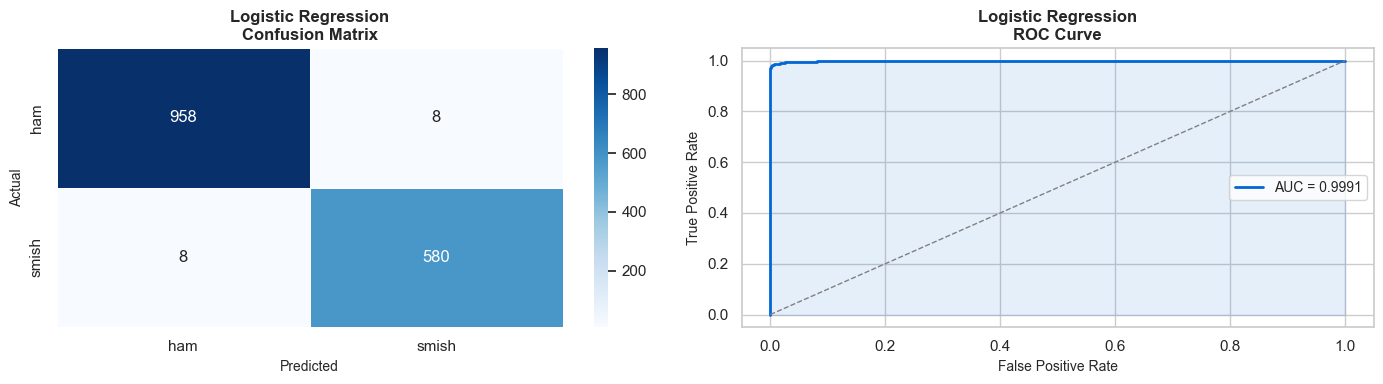

              Model  Accuracy  Precision  Recall     F1  ROC-AUC    FPR    FNR
Logistic Regression    0.9897     0.9864  0.9864 0.9864   0.9991 0.0083 0.0136

────────────────────────────────────────────────────────────
  SVM
────────────────────────────────────────────────────────────
  Best params:   {'svc__C': 10, 'svc__kernel': 'rbf'}
  CV train F1:   1.0000
  CV val   F1:   0.9923  (gap: 0.0077 → OK)


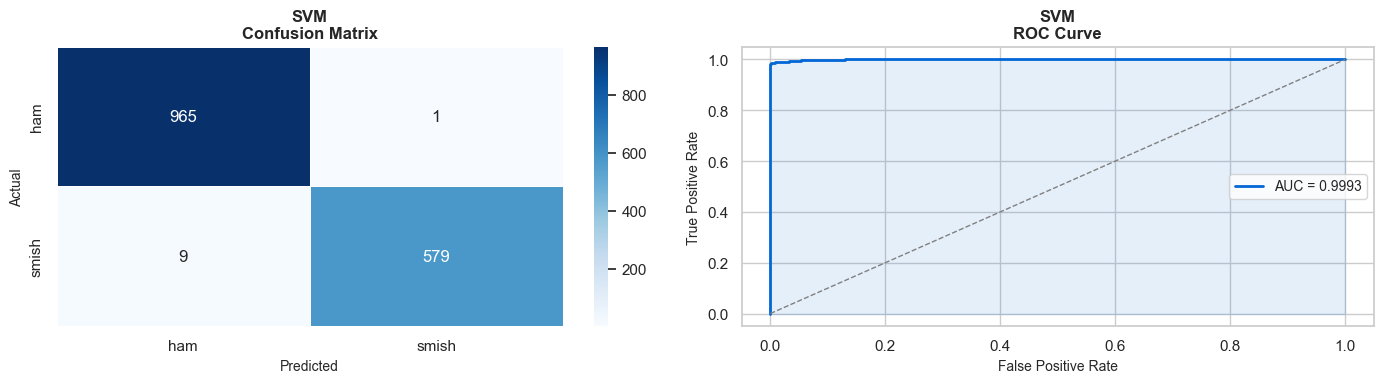

Model  Accuracy  Precision  Recall     F1  ROC-AUC   FPR    FNR
  SVM    0.9936     0.9983  0.9847 0.9914   0.9993 0.001 0.0153

────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────
  Best params:   {'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 200}
  CV train F1:   1.0000
  CV val   F1:   0.9810  (gap: 0.0190 → OK)


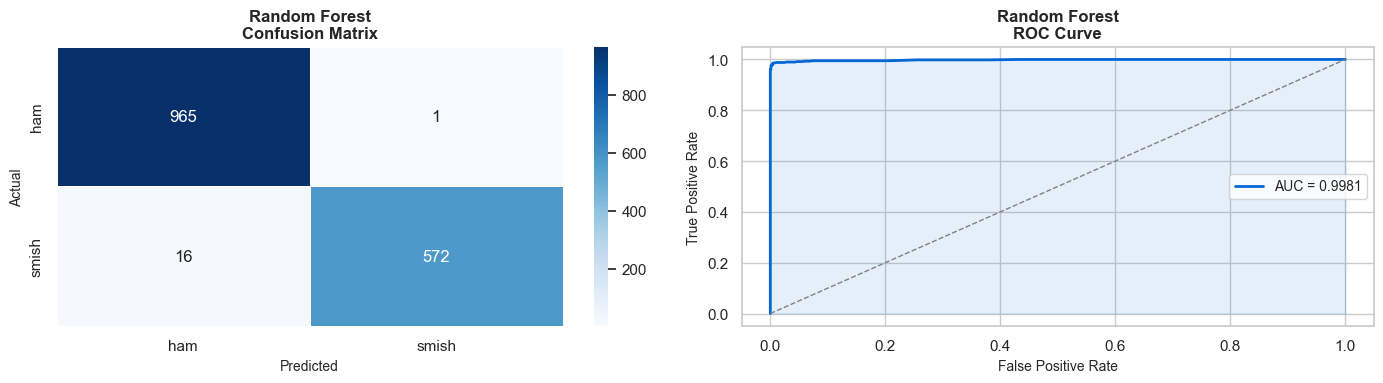

        Model  Accuracy  Precision  Recall     F1  ROC-AUC   FPR    FNR
Random Forest    0.9891     0.9983  0.9728 0.9854   0.9981 0.001 0.0272

────────────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────────────
  Best params:   {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 6, 'xgbclassifier__n_estimators': 200}
  CV train F1:   1.0000
  CV val   F1:   0.9895  (gap: 0.0105 → OK)


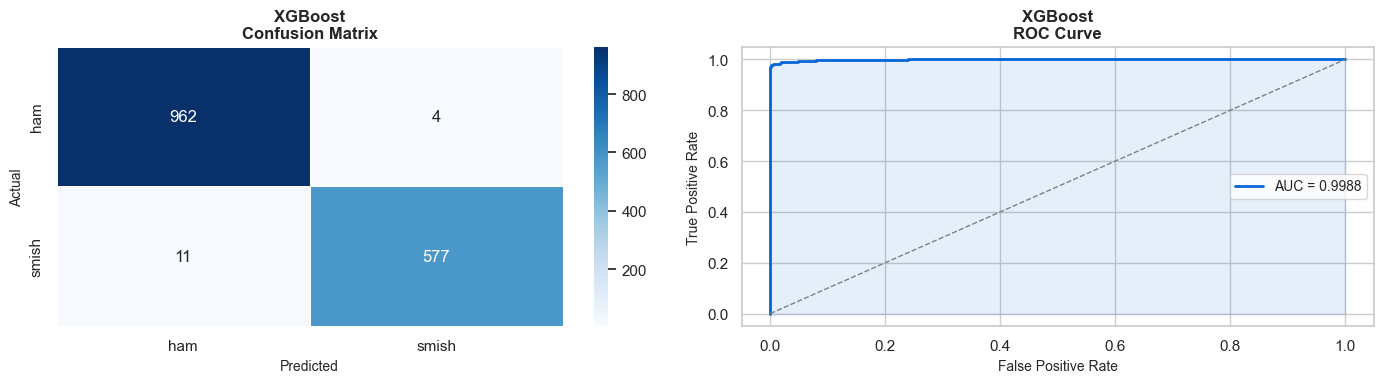

  Model  Accuracy  Precision  Recall     F1  ROC-AUC    FPR    FNR
XGBoost    0.9903     0.9931  0.9813 0.9872   0.9988 0.0041 0.0187

────────────────────────────────────────────────────────────
  MLP
────────────────────────────────────────────────────────────
  Best params:   {'mlpclassifier__alpha': 0.0001, 'mlpclassifier__hidden_layer_sizes': (512, 256)}
  CV train F1:   0.9985
  CV val   F1:   0.9910  (gap: 0.0074 → OK)


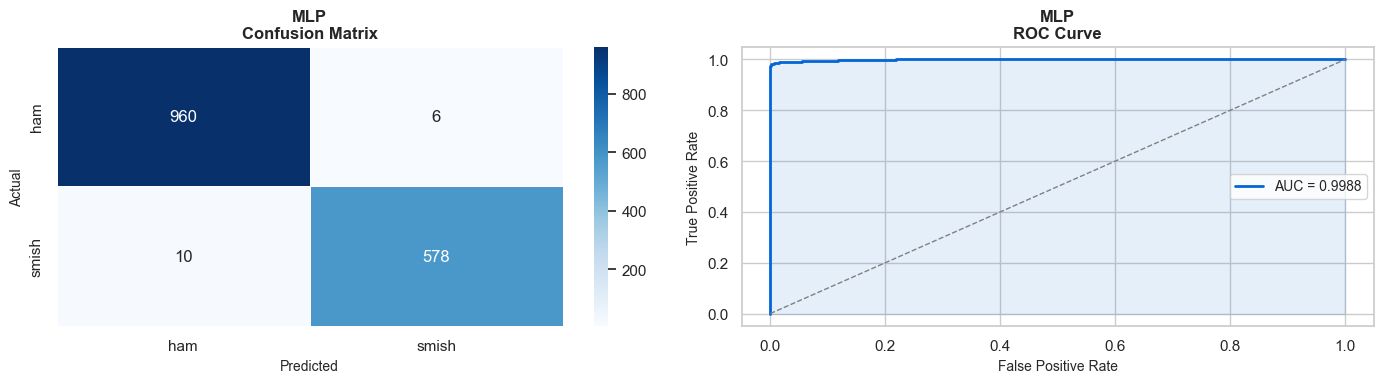

Model  Accuracy  Precision  Recall     F1  ROC-AUC    FPR   FNR
  MLP    0.9897     0.9897   0.983 0.9863   0.9988 0.0062 0.017

BUILDING WEIGHTED SOFT-VOTING ENSEMBLE
Ensemble weights (proportional to individual F1):
  Logistic Regression: 0.9864
  SVM: 0.9914
  Random Forest: 0.9854
  XGBoost: 0.9872
  MLP: 0.9863


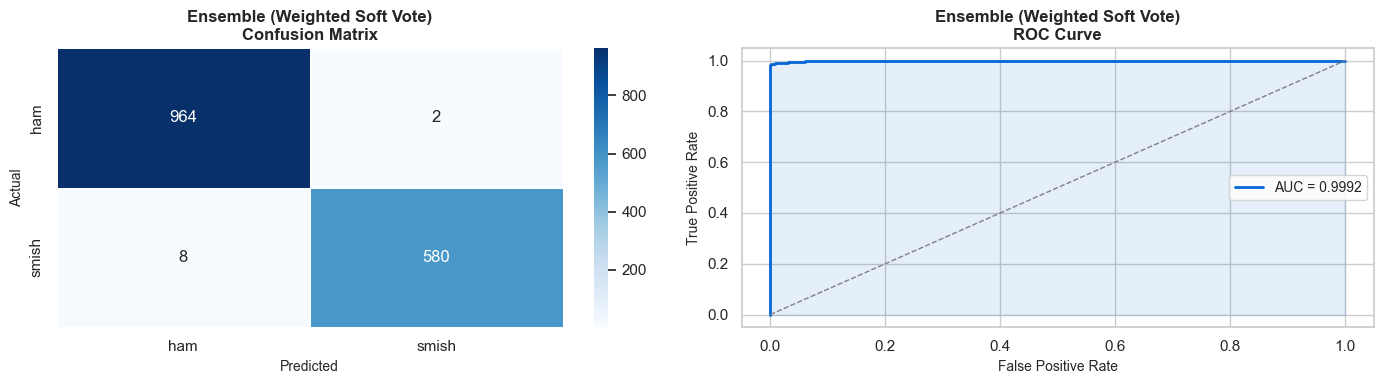

                        Model  Accuracy  Precision  Recall     F1  ROC-AUC    FPR    FNR
Ensemble (Weighted Soft Vote)    0.9936     0.9966  0.9864 0.9915   0.9992 0.0021 0.0136

MODEL COMPARISON (all 6 candidates, sorted by F1)
                        Model  Accuracy  Precision  Recall     F1  ROC-AUC    FPR    FNR
Ensemble (Weighted Soft Vote)    0.9936     0.9966  0.9864 0.9915   0.9992 0.0021 0.0136
                          SVM    0.9936     0.9983  0.9847 0.9914   0.9993 0.0010 0.0153
                      XGBoost    0.9903     0.9931  0.9813 0.9872   0.9988 0.0041 0.0187
          Logistic Regression    0.9897     0.9864  0.9864 0.9864   0.9991 0.0083 0.0136
                          MLP    0.9897     0.9897  0.9830 0.9863   0.9988 0.0062 0.0170
                Random Forest    0.9891     0.9983  0.9728 0.9854   0.9981 0.0010 0.0272

✓ Winner: Ensemble (Weighted Soft Vote)  (F1 = 0.9915)


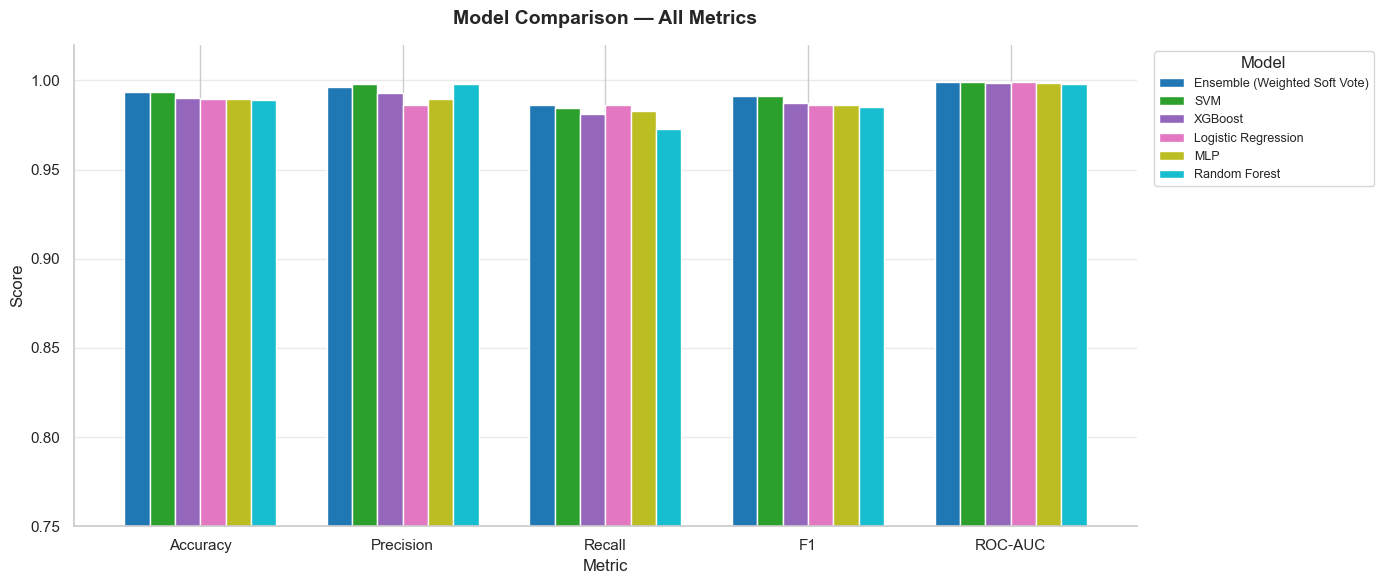

Saved: graphs/07_model_comparison.png

SAVING BEST MODEL
Model saved   → smishing_detector.pkl
Encoder saved → label_encoder.pkl

INFERENCE EXAMPLES

[SMISH] (95.5%) "Congratulations! You have been selected for a FREE prize. Click http:/..."

[SMISH] (95.3%) "Your bank account has been locked. Verify your password at http://secu..."

[HAM] (99.8%) "Hey, are you coming to dinner tonight? Let me know."

[HAM] (99.9%) "Ok lar... Joking wif u oni..."

PIPELINE COMPLETE


In [ ]:
"""
SMS Smishing Detection — ML Model Training Pipeline
====================================================
Trains 5 classifiers + a weighted soft-voting ensemble on SBERT embeddings
combined with engineered text features. Saves the best model to disk.

Run:
    python MLsmish.py

Requires:
    pip install sentence-transformers scikit-learn xgboost joblib pandas numpy matplotlib seaborn
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# Import shared utilities from the NLP preprocessing module
from NLP_smish import (
    preprocess_text, extract_features_from_text,
    SBERT_MODEL_NAME, BATCH_SIZE
)

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
DATASET_PATH  = 'dataset/dataset_with_new_smish_without_spam.csv'
RANDOM_STATE  = 42
TEST_SIZE     = 0.2
CV_FOLDS      = 5
MODEL_PATH    = 'smishing_detector.pkl'
ENCODER_PATH  = 'label_encoder.pkl'
GRAPHS_DIR    = 'graphs'

# Urgency keywords common in phishing messages
URGENCY_WORDS = [
    'free', 'win', 'prize', 'claim', 'click', 'verify', 'urgent',
    'account', 'bank', 'password', 'confirm', 'expire', 'limited',
    'offer', 'reward', 'cash', 'selected', 'congratulations',
    'act now', 'immediately'
]

os.makedirs(GRAPHS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================
def engineer_features(df_input):
    """
    Add 7 text-derived features to the DataFrame.
    Works on both training DataFrames and single-message DataFrames.
    """
    d = df_input.copy()
    d['msg_length']         = d['message'].str.len()
    d['word_count']         = d['message'].str.split().str.len()
    d['uppercase_ratio']    = d['message'].apply(
        lambda m: sum(c.isupper() for c in str(m)) / max(len(str(m)), 1))
    d['digit_count']        = d['message'].apply(lambda m: sum(c.isdigit() for c in str(m)))
    d['special_char_count'] = d['message'].apply(lambda m: sum(c in '!$#*@' for c in str(m)))
    d['urgency_score']      = d['message'].str.lower().apply(
        lambda m: sum(w in m.split() for w in URGENCY_WORDS))
    d['exclamation_count']  = d['message'].str.count('!')
    return d

TEXT_FEATURE_COLS = [
    'msg_length', 'word_count', 'uppercase_ratio', 'digit_count',
    'special_char_count', 'urgency_score', 'exclamation_count'
]

# ============================================================================
# EVALUATION HELPER
# ============================================================================
def model_kpi(model_name, y_true, y_pred, y_proba=None,
              label_encoder=None, save_path=None):
    """
    Compute evaluation metrics and plot confusion matrix + ROC curve.

    Returns:
        metrics_df — DataFrame with Accuracy, Precision, Recall, F1, ROC-AUC, FPR, FNR
        cm         — confusion matrix (numpy array)
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba) if y_proba is not None else float('nan'), 4),
        'FPR':       round(fp / (fp + tn), 4),
        'FNR':       round(fn / (fn + tp), 4),
    }
    metrics_df = pd.DataFrame([metrics])

    class_names = label_encoder.classes_ if label_encoder else ['ham', 'smish']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Confusion matrix
    ax = axes[0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

    # ROC curve
    ax = axes[1]
    if y_proba is not None:
        fpr_vals, tpr_vals, _ = roc_curve(y_true, y_proba)
        auc = metrics['ROC-AUC']
        ax.plot(fpr_vals, tpr_vals, color='#0366d6', lw=2, label=f'AUC = {auc:.4f}')
        ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
        ax.fill_between(fpr_vals, tpr_vals, alpha=0.1, color='#0366d6')
        ax.set_xlabel('False Positive Rate', fontsize=10)
        ax.set_ylabel('True Positive Rate', fontsize=10)
        ax.set_title(f'{model_name}\nROC Curve', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return metrics_df, cm


# ============================================================================
# INFERENCE
# ============================================================================
def predict_message(message_text, model=None, encoder=None, sbert=None):
    """
    Predict whether a raw SMS message is ham or smish.

    Parameters:
        message_text — raw SMS string
        model        — trained classifier (loads smishing_detector.pkl if None)
        encoder      — LabelEncoder (loads label_encoder.pkl if None)
        sbert        — SentenceTransformer (loads SBERT_MODEL_NAME if None)

    Returns:
        (label, confidence) — e.g. ('smish', 0.97)
    """
    if model is None:
        model = joblib.load(MODEL_PATH)
    if encoder is None:
        encoder = joblib.load(ENCODER_PATH)
    if sbert is None:
        sbert = SentenceTransformer(SBERT_MODEL_NAME)

    row = pd.DataFrame([{
        'message': message_text,
        'url': 0, 'email': 0, 'phone': 0
    }])

    # Auto-detect flags from the message text
    feats = extract_features_from_text(message_text)
    row['url']   = feats['url']
    row['email'] = feats['email']
    row['phone'] = feats['phone']

    row = engineer_features(row)

    processed = preprocess_text(message_text)
    embedding = sbert.encode([processed], convert_to_numpy=True)

    flags      = row[['url', 'email', 'phone']].values.astype(float)
    text_feats = row[TEXT_FEATURE_COLS].values.astype(float)
    X_new      = np.hstack([embedding, flags, text_feats])

    pred_int   = model.predict(X_new)[0]
    proba      = model.predict_proba(X_new)[0]
    label_str  = encoder.inverse_transform([pred_int])[0]
    confidence = proba[pred_int]

    return label_str, round(float(confidence), 4)


# ============================================================================
# MAIN TRAINING PIPELINE
# ============================================================================
if __name__ == '__main__':

    # ── Load Dataset ─────────────────────────────────────────────────────────
    print('=' * 70)
    print('LOADING DATASET')
    print('=' * 70)

    df = pd.read_csv(DATASET_PATH)
    print(f'Dataset shape: {df.shape}')
    print(f'Label distribution:\n{df["label"].value_counts().to_string()}\n')

    # ── Feature Engineering ──────────────────────────────────────────────────
    print('=' * 70)
    print('FEATURE ENGINEERING')
    print('=' * 70)

    df = engineer_features(df)

    # Normalize flag columns: yes/Yes/no/No → 1/0
    for col in ['url', 'email', 'phone']:
        df[col] = df[col].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)

    print('Feature means by class:')
    print(df.groupby('label')[TEXT_FEATURE_COLS].mean().round(3).to_string())

    # ── Label Encoding & Train/Test Split ────────────────────────────────────
    print('\n' + '=' * 70)
    print('TRAIN / TEST SPLIT')
    print('=' * 70)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['label'])
    print(f'Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

    feature_df = df[['message', 'url', 'email', 'phone'] + TEXT_FEATURE_COLS]

    X_train_df, X_test_df, y_train, y_test = train_test_split(
        feature_df, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    print(f'Train: {len(X_train_df):,} rows  |  Test: {len(X_test_df):,} rows')

    # ── SBERT Embeddings ─────────────────────────────────────────────────────
    print('\n' + '=' * 70)
    print('NLP PREPROCESSING — SENTENCE-BERT')
    print('=' * 70)

    sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

    X_train_text = X_train_df['message'].apply(preprocess_text).tolist()
    X_test_text  = X_test_df['message'].apply(preprocess_text).tolist()

    print(f'Encoding {len(X_train_text):,} training messages...')
    X_train_sbert = sbert_model.encode(
        X_train_text, batch_size=BATCH_SIZE,
        show_progress_bar=True, convert_to_numpy=True)

    print(f'Encoding {len(X_test_text):,} test messages...')
    X_test_sbert = sbert_model.encode(
        X_test_text, batch_size=BATCH_SIZE,
        show_progress_bar=True, convert_to_numpy=True)

    # ── Assemble Feature Matrices ────────────────────────────────────────────
    X_train_flags     = X_train_df[['url', 'email', 'phone']].values.astype(float)
    X_test_flags      = X_test_df[['url', 'email', 'phone']].values.astype(float)
    X_train_text_f    = X_train_df[TEXT_FEATURE_COLS].values.astype(float)
    X_test_text_f     = X_test_df[TEXT_FEATURE_COLS].values.astype(float)

    X_train = np.hstack([X_train_sbert, X_train_flags, X_train_text_f])
    X_test  = np.hstack([X_test_sbert,  X_test_flags,  X_test_text_f])

    print(f'\nFeature matrix: {X_train.shape[1]} dims  '
          f'(384 SBERT + 3 flags + 7 text)')

    # ── Model Definitions ────────────────────────────────────────────────────
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    models = {
        'Logistic Regression': {
            'pipeline': make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_STATE)
            ),
            'params': {'logisticregression__C': [0.01, 0.1, 1, 10]}
        },
        'SVM': {
            'pipeline': make_pipeline(
                StandardScaler(),
                SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE)
            ),
            'params': {
                'svc__C':      [0.1, 1, 10],
                'svc__kernel': ['rbf', 'linear']
            }
        },
        'Random Forest': {
            'pipeline': make_pipeline(
                RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
            ),
            'params': {
                'randomforestclassifier__n_estimators': [100, 200],
                'randomforestclassifier__max_depth':    [None, 20]
            }
        },
        'XGBoost': {
            'pipeline': make_pipeline(
                XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
            ),
            'params': {
                'xgbclassifier__n_estimators':  [100, 200],
                'xgbclassifier__max_depth':     [4, 6],
                'xgbclassifier__learning_rate': [0.05, 0.1]
            }
        },
        'MLP': {
            'pipeline': make_pipeline(
                StandardScaler(),
                MLPClassifier(max_iter=300, early_stopping=True,
                               random_state=RANDOM_STATE)
            ),
            'params': {
                'mlpclassifier__hidden_layer_sizes': [(256, 128), (512, 256)],
                'mlpclassifier__alpha':              [0.0001, 0.001]
            }
        }
    }

    # ── Train & Evaluate Each Model ──────────────────────────────────────────
    print('\n' + '=' * 70)
    print('TRAINING & EVALUATING MODELS')
    print('=' * 70)

    trained_models = {}
    all_metrics    = []

    for name, config in models.items():
        print(f'\n{"─"*60}')
        print(f'  {name}')
        print(f'{"─"*60}')

        grid = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['params'],
            scoring='f1',
            cv=cv,
            refit=True,
            return_train_score=True,
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)

        best      = grid.best_estimator_
        trained_models[name] = best

        y_pred  = best.predict(X_test)
        y_proba = best.predict_proba(X_test)[:, 1]

        # Overfitting check
        best_idx = grid.best_index_
        train_f1 = grid.cv_results_['mean_train_score'][best_idx]
        val_f1   = grid.cv_results_['mean_test_score'][best_idx]
        gap      = train_f1 - val_f1
        status   = 'OVERFITTING' if gap > 0.05 else 'OK'

        print(f'  Best params:   {grid.best_params_}')
        print(f'  CV train F1:   {train_f1:.4f}')
        print(f'  CV val   F1:   {val_f1:.4f}  (gap: {gap:.4f} → {status})')

        save_path = f'{GRAPHS_DIR}/{name.lower().replace(" ", "_")}_eval.png'
        metrics_df, _ = model_kpi(name, y_test, y_pred, y_proba,
                                   label_encoder=label_encoder,
                                   save_path=save_path)
        print(metrics_df.to_string(index=False))

        all_metrics.append(metrics_df)

    # ── Weighted Soft-Voting Ensemble ────────────────────────────────────────
    print('\n' + '=' * 70)
    print('BUILDING WEIGHTED SOFT-VOTING ENSEMBLE')
    print('=' * 70)

    individual_f1 = {row['Model']: row['F1']
                     for df_m in all_metrics
                     for _, row in df_m.iterrows()}

    estimator_list = [(n.lower().replace(' ', '_'), clf)
                      for n, clf in trained_models.items()]
    weights = [individual_f1[n] for n in trained_models]

    print('Ensemble weights (proportional to individual F1):')
    for n, w in zip(trained_models.keys(), weights):
        print(f'  {n}: {w:.4f}')

    ensemble = VotingClassifier(
        estimators=estimator_list,
        voting='soft',
        weights=weights
    )
    ensemble.fit(X_train, y_train)

    y_pred_ens  = ensemble.predict(X_test)
    y_proba_ens = ensemble.predict_proba(X_test)[:, 1]

    metrics_ens, _ = model_kpi(
        'Ensemble (Weighted Soft Vote)',
        y_test, y_pred_ens, y_proba_ens,
        label_encoder=label_encoder,
        save_path=f'{GRAPHS_DIR}/ensemble_eval.png'
    )
    print(metrics_ens.to_string(index=False))
    all_metrics.append(metrics_ens)

    # ── 6-Way Comparison ─────────────────────────────────────────────────────
    print('\n' + '=' * 70)
    print('MODEL COMPARISON (all 6 candidates, sorted by F1)')
    print('=' * 70)

    comparison_df = pd.concat(all_metrics, ignore_index=True)
    comparison_df = comparison_df.sort_values('F1', ascending=False).reset_index(drop=True)
    print(comparison_df.to_string(index=False))

    winner_name = comparison_df.iloc[0]['Model']
    print(f'\n✓ Winner: {winner_name}  (F1 = {comparison_df.iloc[0]["F1"]:.4f})')

    # Grouped bar chart
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    plot_df = comparison_df.set_index('Model')[metric_cols]

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_df.T.plot(kind='bar', ax=ax, width=0.75,
                   colormap='tab10', edgecolor='white')
    ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Metric', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0.75, 1.02)
    ax.set_xticklabels(metric_cols, rotation=0, fontsize=11)
    ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{GRAPHS_DIR}/07_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {GRAPHS_DIR}/07_model_comparison.png')

    # ── Save Best Model ───────────────────────────────────────────────────────
    print('\n' + '=' * 70)
    print('SAVING BEST MODEL')
    print('=' * 70)

    winner_model = ensemble if winner_name == 'Ensemble (Weighted Soft Vote)' \
                            else trained_models[winner_name]

    joblib.dump(winner_model, MODEL_PATH)
    joblib.dump(label_encoder, ENCODER_PATH)
    print(f'Model saved   → {MODEL_PATH}')
    print(f'Encoder saved → {ENCODER_PATH}')

    # ── Quick Inference Test ──────────────────────────────────────────────────
    print('\n' + '=' * 70)
    print('INFERENCE EXAMPLES')
    print('=' * 70)

    test_messages = [
        'Congratulations! You have been selected for a FREE prize. Click http://claim-now.net immediately!',
        'Your bank account has been locked. Verify your password at http://secure-bank-login.com',
        'Hey, are you coming to dinner tonight? Let me know.',
        'Ok lar... Joking wif u oni...',
    ]

    for msg in test_messages:
        label, conf = predict_message(msg, model=winner_model,
                                      encoder=label_encoder,
                                      sbert=sbert_model)
        indicator = '[SMISH]' if label == 'smish' else '[HAM]'
        short_msg = msg[:70] + '...' if len(msg) > 70 else msg
        print(f'\n{indicator} ({conf:.1%}) "{short_msg}"')

    print('\n' + '=' * 70)
    print('PIPELINE COMPLETE')
    print('=' * 70)